In [7]:
import csv
import sys
from pathlib import Path

def show_table(rows, columns):
    try:
        from IPython.display import HTML, display
        header = "".join(f"<th>{col}</th>" for col in columns)
        body = "".join(
            "<tr>" + "".join(f"<td>{row.get(col, '')}</td>" for col in columns) + "</tr>"
            for row in rows
        )
        display(HTML(f"<table><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>"))
    except Exception:
        widths = {col: max(len(str(col)), *(len(str(row.get(col, ''))) for row in rows)) for col in columns}
        print(" | ".join(str(col).ljust(widths[col]) for col in columns))
        print("-+-".join("-" * widths[col] for col in columns))
        for row in rows:
            print(" | ".join(str(row.get(col, '')).ljust(widths[col]) for col in columns))

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != "TEAM_1" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from models.role02_star.head_first_rules import analyze_head_first
from models.role02_star.head_first_classifier import classify_head_first
from models.role02_star.number_ner import detect_result_numbers
from models.role02_star.star_scorer import score_star_completeness
from models.role02_star.visualize import plot_role02_requirement_status, plot_role02_summary, plot_star_radar


[데이터셋] data/processed/jobkorea_train.csv
전체 행 수: 24609
답변 있는 행 수: 23857
분석 대상 답변 수: 3

[분석 요약]


지표,결과,점수,근거/피드백
핵심 주장 명확성,❌,0,"첫 문장에 핵심 역량, 성과, 문제 해결 경험을 더 직접적으로 제시하세요."
경험 구체성,S✅ T✅ A✅ R✅,100,S✅ T✅ A✅ R✅ S/T/A/R 요소가 모두 확인됩니다.



[STAR 체크리스트]


요소,충족,근거 키워드
S,✅,"당시, 문제, 프로젝트"
T,✅,요구
A,✅,"도입, 진행"
R,✅,"결과, 해결"



[답변별 데이터셋 확인]


No,기업,문항번호,답변
1,금융결제원,1,"""최고가 되기 위해서"" 금융결제원은 국내 다양한 금융 관련 서비스를 지원하는 최고의 기업입니다. 이런 여러 서비스 운영에 있어 중요한 것은 사용자에게 적절한 UI의 표출, 그리고 효율적인 데이터 처리를 통한 빠른"
2,금융결제원,2,"금융결제원이 제공하는 서비스는 매우 다양하며, 저는 개인적으로 금융공동망과 인터넷지로 서비스를 이용해 본 경험이 있습니다. 금융공동망은 금융기관 간의 자금 이체를 실시간으로 처리하는 시스템으로, 이를 이용하면 다른"
3,금융결제원,3,"""노력의 발자취"" 개인 프로젝트 중 기억에 남는 것은 member의 id를 통해 이름을 가져오기 위한 fetch join을 사용해 여러 값들을 한꺼번에 가져오는 것이었습니다. 제가 해당 프로젝트에서 진행한 내용은"



[시각화]
models/role02_star/figures/role02_notebook_star_radar.png
models/role02_star/figures/role02_notebook_summary.png
models/role02_star/figures/role02_notebook_requirement_status.png


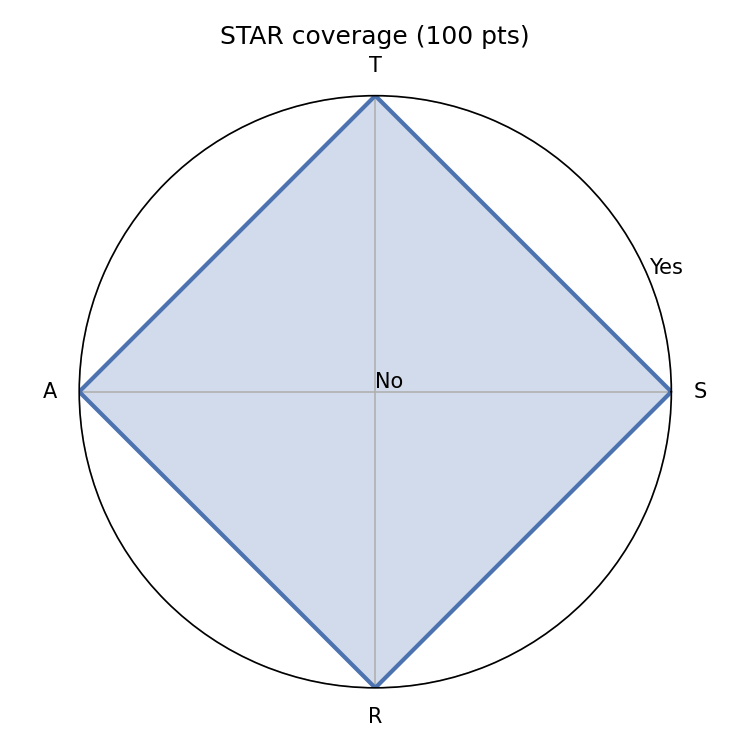

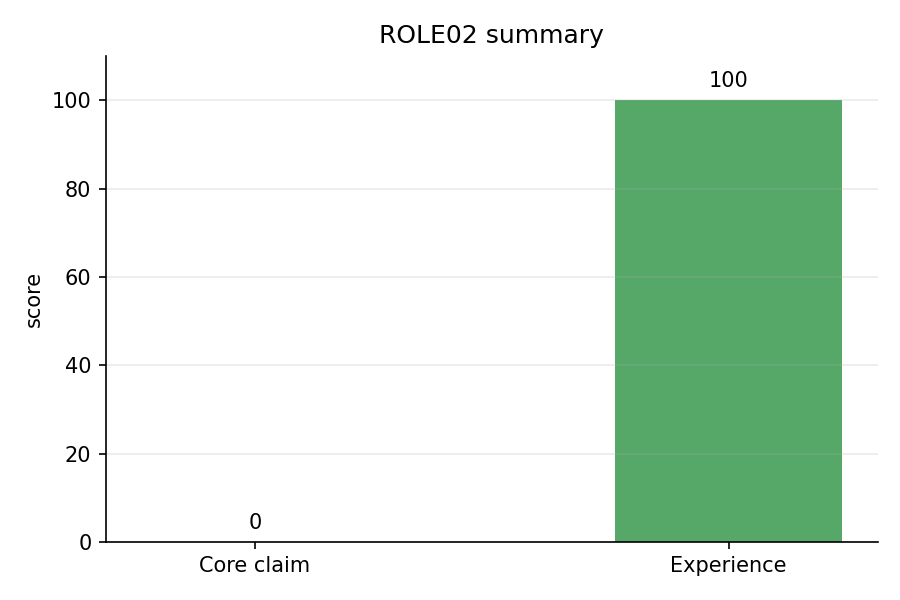

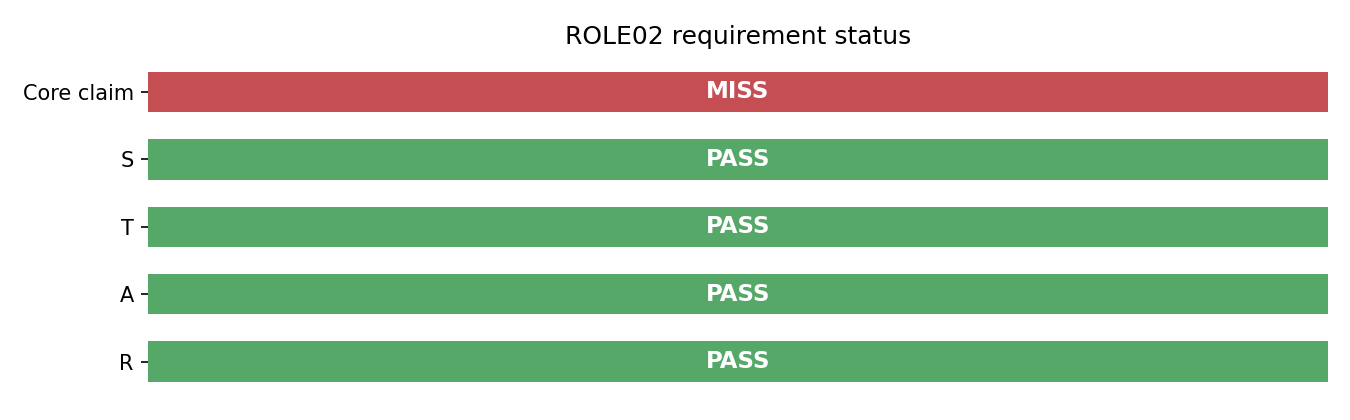

In [8]:
dataset_path = PROJECT_ROOT / "data" / "processed" / "jobkorea_train.csv"
DEMO_ANSWER_COUNT = 3

with dataset_path.open(encoding="utf-8-sig") as f:
    rows = list(csv.DictReader(f))

answer_rows = [row for row in rows if row.get("answer", "").strip()]
demo_rows = answer_rows[:DEMO_ANSWER_COUNT]
answer_text = " ".join(row["answer"] for row in demo_rows)
head = analyze_head_first(answer_text)
head_binary = classify_head_first(answer_text)
star = score_star_completeness(answer_text)
numbers = detect_result_numbers(answer_text)
figure_dir = PROJECT_ROOT / "models" / "role02_star" / "figures"
star_radar_path = plot_star_radar(star, figure_dir / "role02_notebook_star_radar.png")
summary_path = plot_role02_summary(head_binary, star, numbers, figure_dir / "role02_notebook_summary.png")
status_path = plot_role02_requirement_status(
    head_binary,
    star,
    numbers,
    figure_dir / "role02_notebook_requirement_status.png",
)

print(f"[데이터셋] {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"전체 행 수: {len(rows)}")
print(f"답변 있는 행 수: {len(answer_rows)}")
print(f"분석 대상 답변 수: {len(demo_rows)}")

summary_rows = [
    {
        "지표": "핵심 주장 명확성",
        "결과": head["display"],
        "점수": head["is_head_first"],
        "근거/피드백": head["reason"],
    },
    {
        "지표": "경험 구체성",
        "결과": star["display"],
        "점수": star["score"],
        "근거/피드백": star["feedback"],
    },
]

print("\n[분석 요약]")
show_table(summary_rows, ["지표", "결과", "점수", "근거/피드백"])

star_rows = [
    {
        "요소": code,
        "충족": "✅" if star["checklist"][code] else "❌",
        "근거 키워드": ", ".join(star["evidence"][code]) or "-",
    }
    for code in ["S", "T", "A", "R"]
]
print("\n[STAR 체크리스트]")
show_table(star_rows, ["요소", "충족", "근거 키워드"])

answer_table_rows = []
for index, row in enumerate(demo_rows, start=1):
    answer_table_rows.append({
        "No": index,
        "기업": row["company"],
        "문항번호": row["question_no"],
        "답변": row["answer"].replace("\n", " ")[:120],
    })
print("\n[답변별 데이터셋 확인]")
show_table(answer_table_rows, ["No", "기업", "문항번호", "답변"])

print("\n[시각화]")
print(star_radar_path.relative_to(PROJECT_ROOT))
print(summary_path.relative_to(PROJECT_ROOT))
print(status_path.relative_to(PROJECT_ROOT))
try:
    from IPython.display import Image, display
    display(Image(filename=str(star_radar_path)))
    display(Image(filename=str(summary_path)))
    display(Image(filename=str(status_path)))
except Exception:
    pass
